Pearson r (Awakenings vs SE%): 0.301
Spearman rho (Awakenings vs SE%): 0.297
  subject_id     SE_pct     N3_pct  num_transitions  num_awakenings
0     SC4001  24.641509  33.690658            112.0            11.0
1     SC4002  33.368682  31.461864            119.0            22.0
2     SC4011  33.761599  11.099366            109.0            14.0
3     SC4012  35.955056   9.375000            154.0            16.0
4     SC4021  31.990014  10.590858            134.0             8.0
Saved: efficiency_vs_awakenings.png, sleep_fragmentation_top15.png, subject_fragmentation_analysis.csv


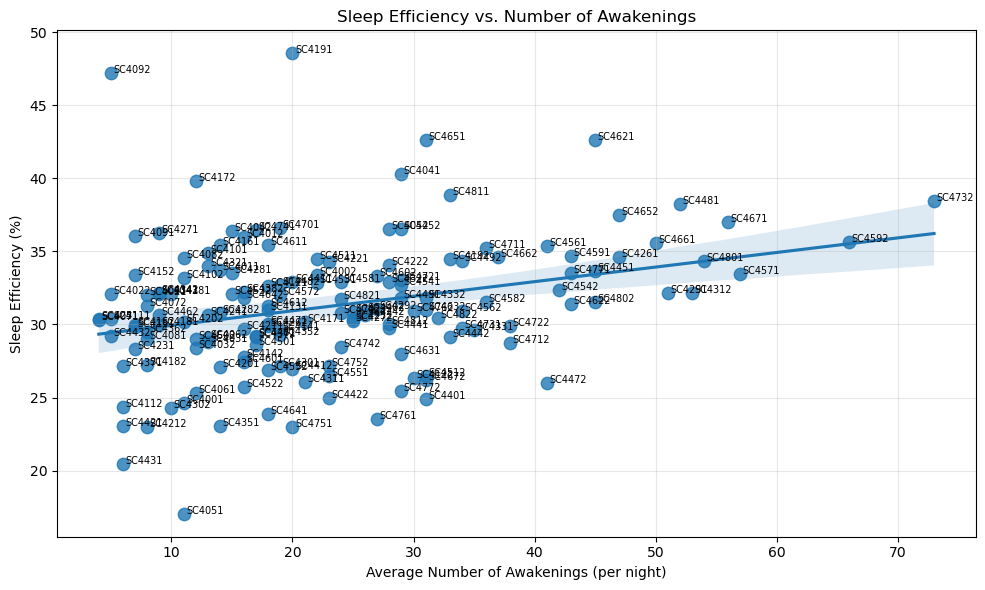

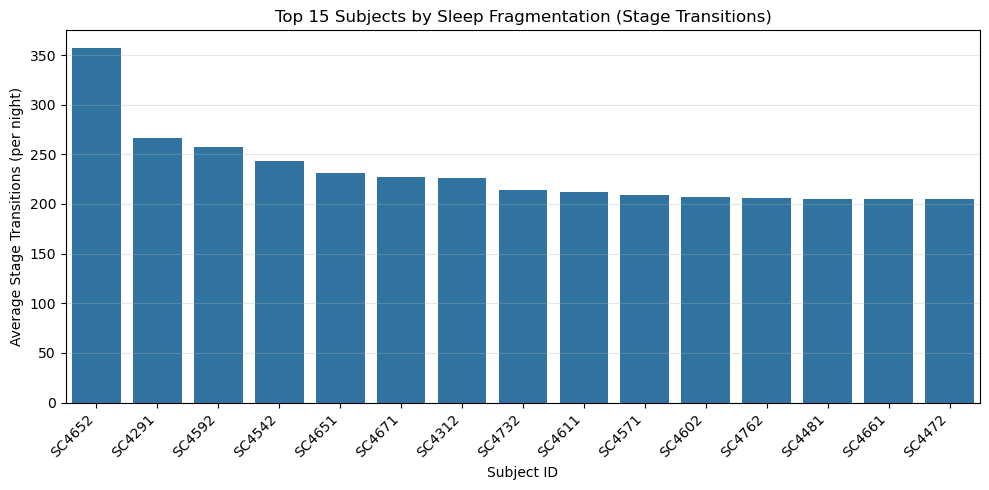

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1) Load data
# -------------------------
df = pd.read_csv('../datasets/sleepedf_SC_merged_epochs.csv')

# -------------------------
# 2) Create subject_id + ensure correct ordering
# -------------------------
# Example: SC4001E0 -> SC4001
df['subject_id'] = df['recording_id'].str.extract(r'^(SC\d{4})', expand=False)

# Optional: night/session indicator (E0/E1)
df['night_id'] = df['recording_id'].str.extract(r'(E\d)$', expand=False)

# Sort by recording and epoch to ensure temporal order
df = df.sort_values(['recording_id', 'epoch']).copy()

# -------------------------
# 3) Transition metrics per recording
# -------------------------
def analyze_transitions(group: pd.DataFrame) -> pd.Series:
    g = group.copy()
    g['prev_stage'] = g['sleep_stage'].shift(1)

    # Count stage changes; subtract 1 to exclude the first row (prev_stage is NaN)
    num_transitions = (g['sleep_stage'] != g['prev_stage']).sum() - 1
    num_transitions = max(int(num_transitions), 0)

    # Awakenings: transitions from any sleep stage -> W
    sleep_stages = ['N1', 'N2', 'N3', 'REM']
    awakenings = g[(g['prev_stage'].isin(sleep_stages)) & (g['sleep_stage'] == 'W')]
    num_awakenings = int(len(awakenings))

    return pd.Series({
        'num_transitions': num_transitions,
        'num_awakenings': num_awakenings
    })

# Pandas FutureWarning-safe apply (with fallback for older pandas)
grouped_rec = df.groupby(['subject_id', 'recording_id'], group_keys=False)

try:
    trans_metrics = grouped_rec.apply(analyze_transitions, include_groups=False).reset_index()
except TypeError:
    # Older pandas doesn't support include_groups
    trans_metrics = grouped_rec.apply(analyze_transitions).reset_index()

# Aggregate to subject level (average across recordings/nights)
subject_trans = trans_metrics.groupby('subject_id').mean(numeric_only=True).reset_index()

# -------------------------
# 4) Base sleep metrics per recording, then subject-level average
# -------------------------
def calculate_metrics(group: pd.DataFrame) -> pd.Series:
    total = len(group)
    counts = group['sleep_stage'].value_counts()

    # Total Sleep Time (epochs): N1+N2+N3+REM
    tst = counts.get('N1', 0) + counts.get('N2', 0) + counts.get('N3', 0) + counts.get('REM', 0)

    # Sleep efficiency based on epoch counts (sleep epochs / total epochs)
    se = (tst / total) * 100 if total > 0 else 0

    # N3 percentage within sleep epochs
    n3_pct = (counts.get('N3', 0) / tst * 100) if tst > 0 else 0

    return pd.Series({'SE_pct': se, 'N3_pct': n3_pct})

grouped_rec2 = df.groupby(['subject_id', 'recording_id'], group_keys=False)

try:
    base_metrics = grouped_rec2.apply(calculate_metrics, include_groups=False).reset_index()
except TypeError:
    base_metrics = grouped_rec2.apply(calculate_metrics).reset_index()

subject_base = (
    base_metrics.groupby('subject_id')
    .mean(numeric_only=True)
    .reset_index()
)

# -------------------------
# 5) Merge into final subject-level summary
# -------------------------
final_summary = pd.merge(subject_base, subject_trans, on='subject_id', how='inner')

# -------------------------
# 6) Correlation stats (for paper + sanity)
# -------------------------
pearson_r = final_summary['num_awakenings'].corr(final_summary['SE_pct'])
spearman_rho = final_summary['num_awakenings'].corr(final_summary['SE_pct'], method='spearman')

print(f"Pearson r (Awakenings vs SE%): {pearson_r:.3f}")
print(f"Spearman rho (Awakenings vs SE%): {spearman_rho:.3f}")

# -------------------------
# 7) Plot 1: Sleep Efficiency vs Awakenings
# -------------------------
plt.figure(figsize=(10, 6))
sns.regplot(
    data=final_summary,
    x='num_awakenings',
    y='SE_pct',
    scatter_kws={'s': 80}
)

# Label points (can get crowded; keep it if you want IDs visible)
for _, row in final_summary.iterrows():
    plt.text(row['num_awakenings'] + 0.2, row['SE_pct'], row['subject_id'], fontsize=7)

plt.title('Sleep Efficiency vs. Number of Awakenings')
plt.xlabel('Average Number of Awakenings (per night)')
plt.ylabel('Sleep Efficiency (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('efficiency_vs_awakenings.png', dpi=300)

# -------------------------
# 8) Plot 2 (Option A): Top 15 most fragmented subjects
# -------------------------
topk = 15
plot_df = final_summary.sort_values('num_transitions', ascending=False).head(topk)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x='subject_id', y='num_transitions')
plt.title(f'Top {topk} Subjects by Sleep Fragmentation (Stage Transitions)')
plt.ylabel('Average Stage Transitions (per night)')
plt.xlabel('Subject ID')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('sleep_fragmentation_top15.png', dpi=300)

# -------------------------
# 9) Save final table
# -------------------------
print(final_summary.head())
final_summary.to_csv('subject_fragmentation_analysis.csv', index=False)
print("Saved: efficiency_vs_awakenings.png, sleep_fragmentation_top15.png, subject_fragmentation_analysis.csv")



In [5]:
print(df['subject_id'].isna().mean())  # should be 0.0
print(df[['recording_id','subject_id']].drop_duplicates().head(10))



0.0
      recording_id subject_id
0         SC4001E0     SC4001
2650      SC4002E0     SC4002
5479      SC4011E0     SC4011
8281      SC4012E0     SC4012
11129     SC4021E0     SC4021
13933     SC4022E0     SC4022
16688     SC4031E0     SC4031
19508     SC4032E0     SC4032
22240     SC4041E0     SC4041
24809     SC4042E0     SC4042
